# Evaluate


In [ ]:
# Parameters (papermill-friendly)
seed = 42
data_dir = 'data'
processed_dir = 'data/processed'


In [1]:
%pip install -q xgboost seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
)

import xgboost as xgb

sns.set_style('whitegrid')

In [5]:
# Load cleaned data
df = pd.read_csv("../data/processed/FICO_cleaned2.csv")

# Prepare features and target (matching training process)
X = df.drop(columns=["RiskPerformance"])
y = df["RiskPerformance"]
y = 1 - y  # Invert labels to match training (Bad=1, Good=0)

print(f"Data shape: {df.shape}")
print(f"Class distribution:\n{y.value_counts()}")

Data shape: (10459, 24)
Class distribution:
RiskPerformance
1    5459
0    5000
Name: count, dtype: int64


In [6]:
# Recreate train/test splits (must match training notebook for fair comparison)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

Train: (6693, 23), Valid: (1674, 23), Test: (2092, 23)


In [7]:
from scipy.stats import spearmanr

# Compute monotonic constraints based on Spearman correlation
# This ensures predictions align with domain knowledge
monotone_dir = {}
for col in X.columns:
    # Get valid (non-missing) observations
    valid_mask = (~X[col].isna()) & (~y.isna())
    x_col_valid = X.loc[valid_mask, col]
    y_col_valid = y.loc[valid_mask]
    
    # Skip if insufficient data or no variance
    if len(x_col_valid) < 10 or x_col_valid.nunique() < 2:
        monotone_dir[col] = 0
        continue
    
    # Compute Spearman correlation with target
    corr, _ = spearmanr(x_col_valid, y_col_valid)
    
    # Set constraint: -1 (decreasing), 0 (no constraint), 1 (increasing)
    if np.isnan(corr) or abs(corr) < 0.1:
        monotone_dir[col] = 0  # Weak correlation -> no constraint
    else:
        monotone_dir[col] = 1 if corr > 0 else -1

# Convert to XGBoost format
constraints_list = [monotone_dir[col] for col in X.columns]
monotone_constraints_str = "(" + ",".join(str(v) for v in constraints_list) + ")"

print("Monotonic Constraints Applied:")
print(f"  Total features: {len(monotone_dir)}")
print(f"  Increasing (1): {sum(1 for v in monotone_dir.values() if v == 1)}")
print(f"  Decreasing (-1): {sum(1 for v in monotone_dir.values() if v == -1)}")
print(f"  No constraint (0): {sum(1 for v in monotone_dir.values() if v == 0)}")
print(f"\nConstraints string: {monotone_constraints_str}")

Monotonic Constraints Applied:
  Total features: 23
  Increasing (1): 9
  Decreasing (-1): 10
  No constraint (0): 4

Constraints string: (-1,-1,0,-1,-1,1,1,-1,-1,-1,-1,-1,0,1,-1,1,1,1,0,1,0,1,1)


In [8]:

n_bad = y_train_full.sum()
n_good = len(y_train_full) - n_bad
scale_pos_weight = n_good / n_bad

model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    use_label_encoder=False,
    random_state=42,
    early_stopping_rounds=50,
    
    monotone_constraints=monotone_constraints_str, 
    subsample=0.75,
    reg_lambda=0,
    reg_alpha=1,
    n_estimators=600,
    min_child_weight=10,
    max_depth=4,
    learning_rate=0.01,
    gamma=0,
    colsample_bytree=0.6,
    scale_pos_weight=scale_pos_weight,
)

print("Training model...")
model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=50,
)

print(f"\nBest iteration: {model.best_iteration}")

Training model...
[0]	validation_0-auc:0.79226
[0]	validation_0-auc:0.79226


c:\Users\giris\CMPE257-Project\.venv\Lib\site-packages\xgboost\callback.py:386: UserWarning: [19:24:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-auc:0.80978
[100]	validation_0-auc:0.81129
[100]	validation_0-auc:0.81129
[150]	validation_0-auc:0.81361
[150]	validation_0-auc:0.81361
[200]	validation_0-auc:0.81482
[200]	validation_0-auc:0.81482
[250]	validation_0-auc:0.81607
[250]	validation_0-auc:0.81607
[300]	validation_0-auc:0.81695
[300]	validation_0-auc:0.81695
[350]	validation_0-auc:0.81776
[350]	validation_0-auc:0.81776
[400]	validation_0-auc:0.81794
[400]	validation_0-auc:0.81794
[450]	validation_0-auc:0.81780
[450]	validation_0-auc:0.81780
[461]	validation_0-auc:0.81764
[461]	validation_0-auc:0.81764

Best iteration: 411

Best iteration: 411


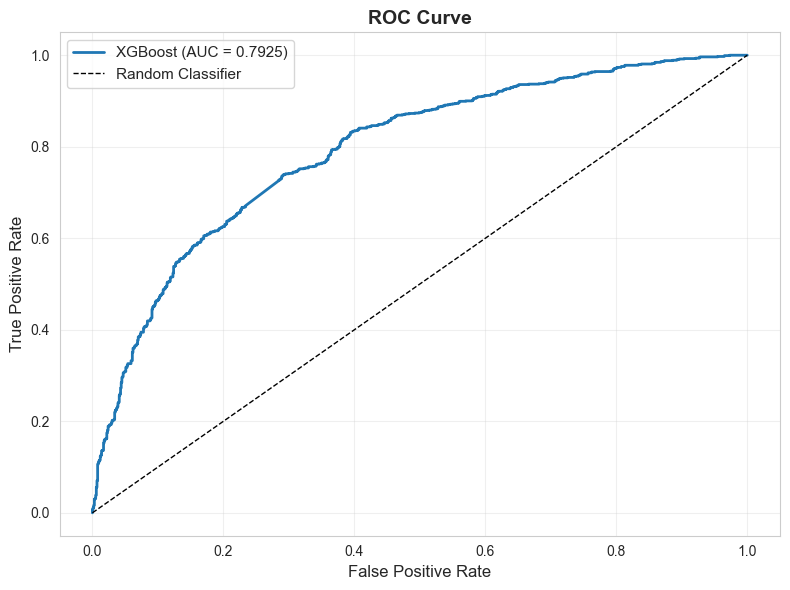

ROC-AUC Score: 0.7925


In [9]:
# Get predictions on test set
y_proba_test = model.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba_test)
auc_score = roc_auc_score(y_test, y_proba_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")

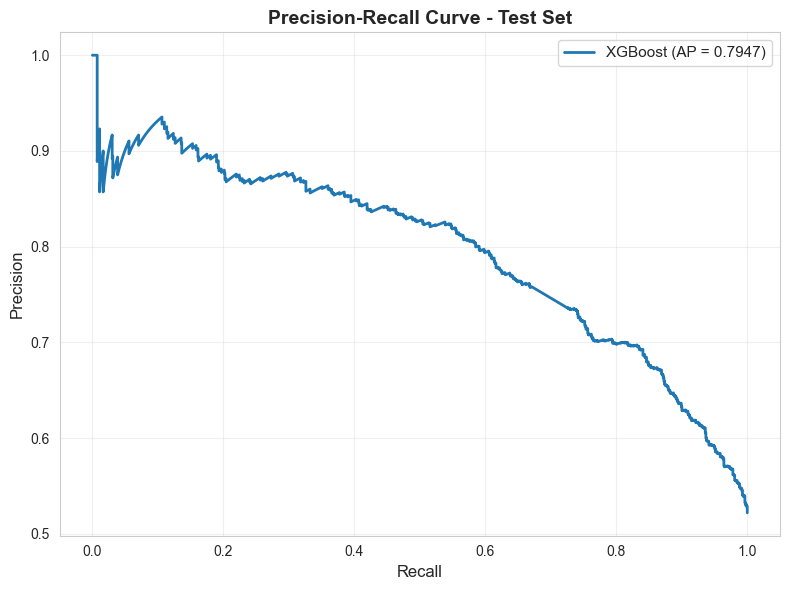

Average Precision Score: 0.7947


In [10]:
# Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba_test)
avg_precision = average_precision_score(y_test, y_proba_test)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2, label=f'XGBoost (AP = {avg_precision:.4f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Test Set', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Precision Score: {avg_precision:.4f}")

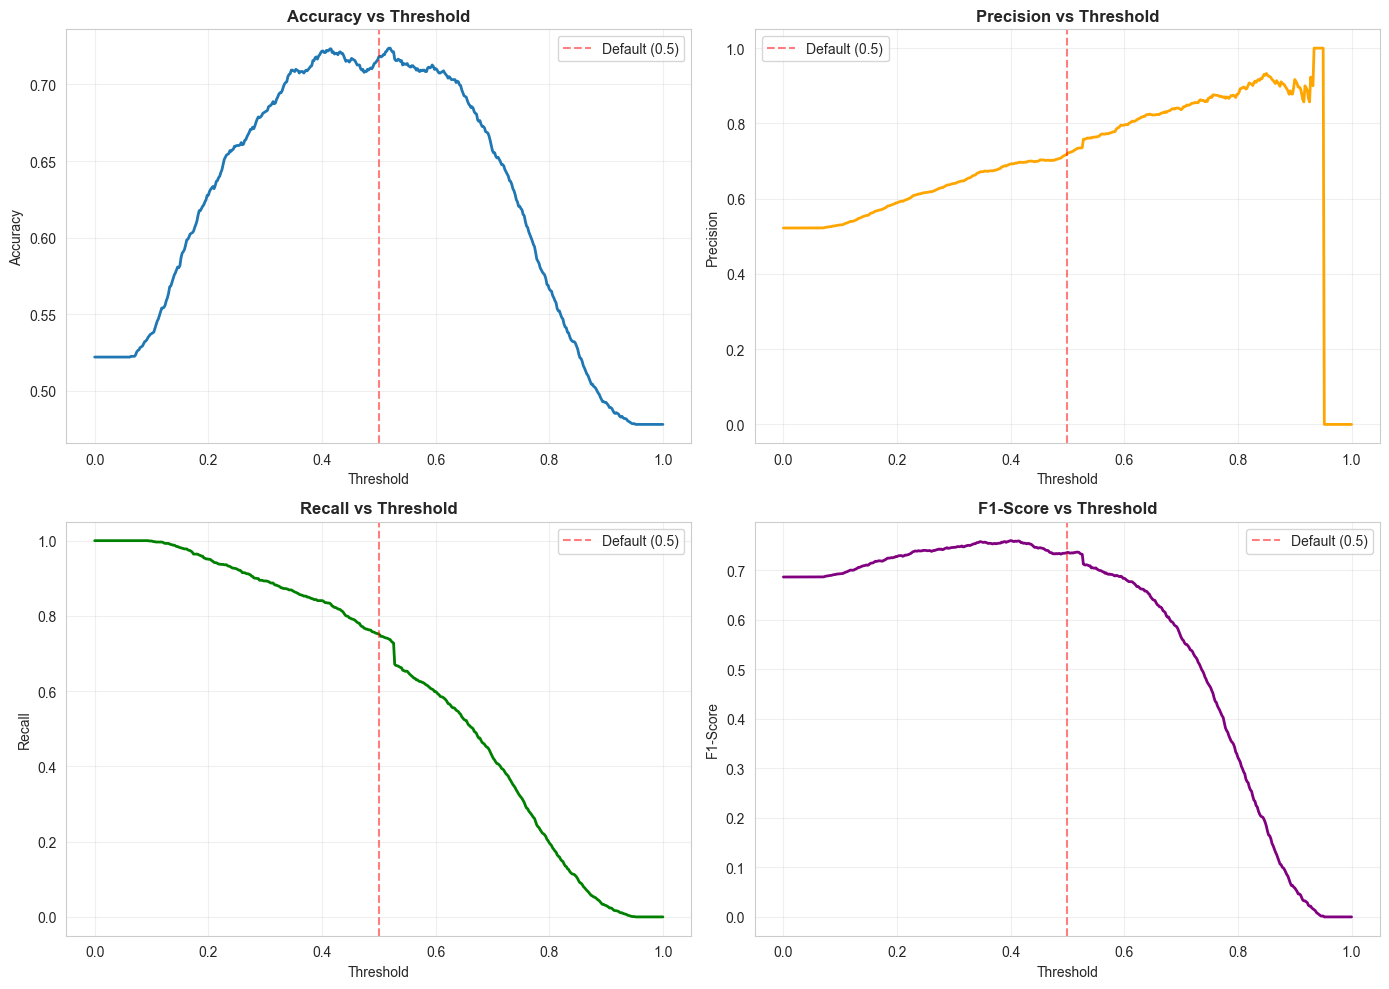

Best threshold by F1-Score:
threshold    0.400000
accuracy     0.721797
precision    0.692308
recall       0.840659
f1           0.759305
Name: 200, dtype: float64


Best threshold by Accuracy:
threshold    0.518000
accuracy     0.723709
precision    0.734062
recall       0.738095
f1           0.736073
Name: 259, dtype: float64


In [12]:
# Test multiple thresholds
thresholds = np.linspace(0.0, 1.0, 501)
results = []

for t in thresholds:
    y_pred_t = (y_proba_test >= t).astype(int)
    
    results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
    })

results_df = pd.DataFrame(results)

# Plot metrics vs threshold
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(results_df['threshold'], results_df['accuracy'], linewidth=2)
axes[0, 0].set_title('Accuracy vs Threshold', fontweight='bold')
axes[0, 0].set_xlabel('Threshold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0, 0].legend()

axes[0, 1].plot(results_df['threshold'], results_df['precision'], linewidth=2, color='orange')
axes[0, 1].set_title('Precision vs Threshold', fontweight='bold')
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0, 1].legend()

axes[1, 0].plot(results_df['threshold'], results_df['recall'], linewidth=2, color='green')
axes[1, 0].set_title('Recall vs Threshold', fontweight='bold')
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[1, 0].legend()

axes[1, 1].plot(results_df['threshold'], results_df['f1'], linewidth=2, color='purple')
axes[1, 1].set_title('F1-Score vs Threshold', fontweight='bold')
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Find best thresholds for different objectives
print("Best threshold by F1-Score:")
best_f1_idx = results_df['f1'].idxmax()
print(results_df.iloc[best_f1_idx])

print("\n" + "="*60)
print("\nBest threshold by Accuracy:")
best_acc_idx = results_df['accuracy'].idxmax()
print(results_df.iloc[best_acc_idx])

PERFORMANCE AT THRESHOLD = 0.5 (Default)
              precision    recall  f1-score   support

    Good (0)       0.72      0.68      0.70      1000
     Bad (1)       0.72      0.75      0.74      1092

    accuracy                           0.72      2092
   macro avg       0.72      0.72      0.72      2092
weighted avg       0.72      0.72      0.72      2092


PERFORMANCE AT THRESHOLD = 0.400 (Optimized for F1)
              precision    recall  f1-score   support

    Good (0)       0.77      0.59      0.67      1000
     Bad (1)       0.69      0.84      0.76      1092

    accuracy                           0.72      2092
   macro avg       0.73      0.72      0.71      2092
weighted avg       0.73      0.72      0.72      2092



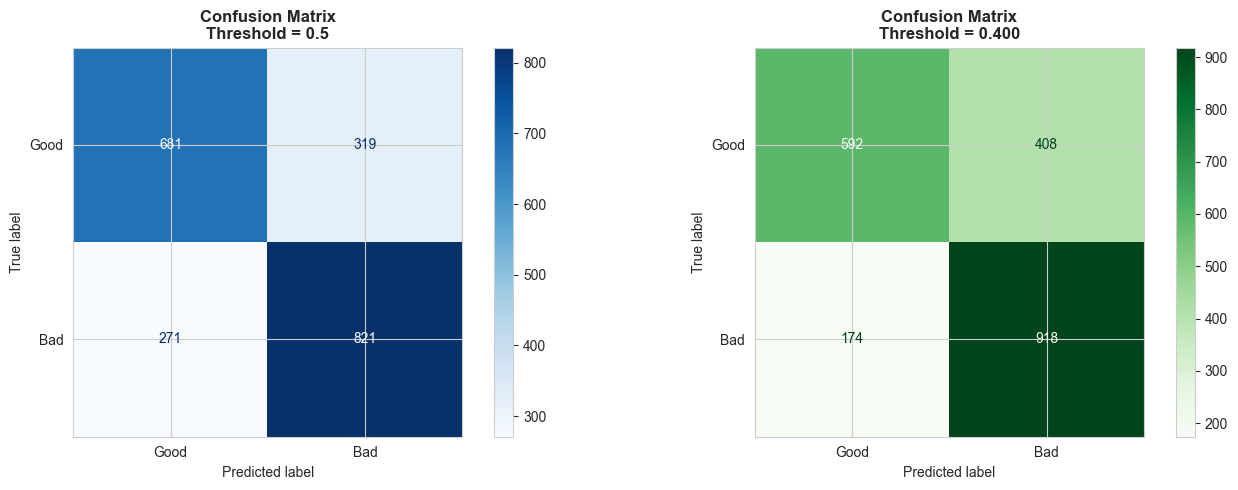

In [13]:
# Compare default threshold vs optimized
optimal_threshold = results_df.iloc[best_f1_idx]['threshold']

y_pred_default = (y_proba_test >= 0.5).astype(int)
y_pred_optimal = (y_proba_test >= optimal_threshold).astype(int)

print("=" * 70)
print("PERFORMANCE AT THRESHOLD = 0.5 (Default)")
print("=" * 70)
print(classification_report(y_test, y_pred_default, target_names=['Good (0)', 'Bad (1)']))

print("\n" + "=" * 70)
print(f"PERFORMANCE AT THRESHOLD = {optimal_threshold:.3f} (Optimized for F1)")
print("=" * 70)
print(classification_report(y_test, y_pred_optimal, target_names=['Good (0)', 'Bad (1)']))

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_default = confusion_matrix(y_test, y_pred_default)
disp_default = ConfusionMatrixDisplay(confusion_matrix=cm_default, display_labels=['Good', 'Bad'])
disp_default.plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix\nThreshold = 0.5', fontweight='bold')

cm_optimal = confusion_matrix(y_test, y_pred_optimal)
disp_optimal = ConfusionMatrixDisplay(confusion_matrix=cm_optimal, display_labels=['Good', 'Bad'])
disp_optimal.plot(ax=axes[1], cmap='Greens')
axes[1].set_title(f'Confusion Matrix\nThreshold = {optimal_threshold:.3f}', fontweight='bold')

plt.tight_layout()
plt.show()

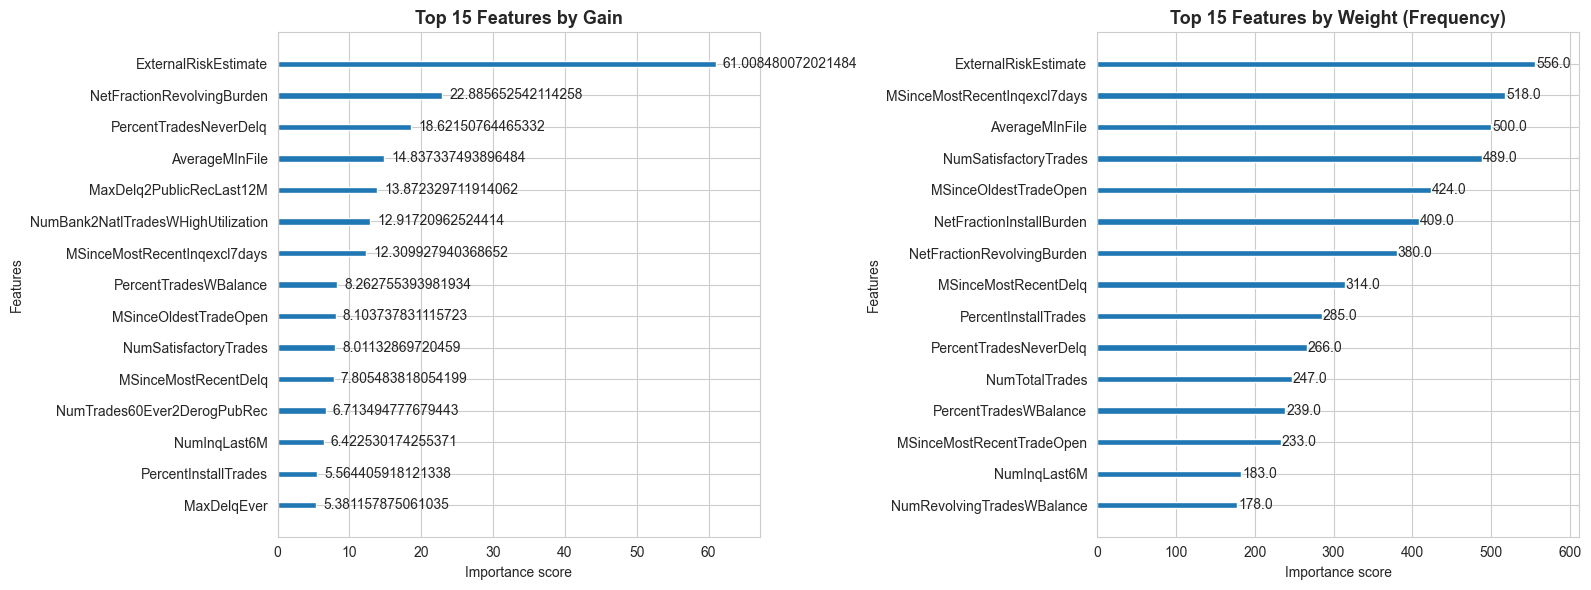

In [14]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gain-based importance
xgb.plot_importance(model, max_num_features=15, importance_type='gain', ax=axes[0])
axes[0].set_title('Top 15 Features by Gain', fontweight='bold', fontsize=13)

# Weight-based importance (frequency)
xgb.plot_importance(model, max_num_features=15, importance_type='weight', ax=axes[1])
axes[1].set_title('Top 15 Features by Weight (Frequency)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

In [15]:
# Create comprehensive summary table
summary = pd.DataFrame({
    'Metric': [
        'ROC-AUC',
        'Average Precision',
        'Accuracy',
        'Precision (Bad)',
        'Recall (Bad)',
        'F1-Score (Bad)',
        'Precision (Good)',
        'Recall (Good)',
        'F1-Score (Good)',
    ],
    'Threshold = 0.5': [
        auc_score,
        avg_precision,
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default, pos_label=1),
        recall_score(y_test, y_pred_default, pos_label=1),
        f1_score(y_test, y_pred_default, pos_label=1),
        precision_score(y_test, y_pred_default, pos_label=0),
        recall_score(y_test, y_pred_default, pos_label=0),
        f1_score(y_test, y_pred_default, pos_label=0),
    ],
    f'Threshold = {optimal_threshold:.3f}': [
        auc_score,
        avg_precision,
        accuracy_score(y_test, y_pred_optimal),
        precision_score(y_test, y_pred_optimal, pos_label=1),
        recall_score(y_test, y_pred_optimal, pos_label=1),
        f1_score(y_test, y_pred_optimal, pos_label=1),
        precision_score(y_test, y_pred_optimal, pos_label=0),
        recall_score(y_test, y_pred_optimal, pos_label=0),
        f1_score(y_test, y_pred_optimal, pos_label=0),
    ]
})

print("\n" + "="*80)
print("COMPREHENSIVE MODEL PERFORMANCE SUMMARY")
print("="*80)
print(summary.to_string(index=False))
print("="*80)


COMPREHENSIVE MODEL PERFORMANCE SUMMARY
           Metric  Threshold = 0.5  Threshold = 0.400
          ROC-AUC         0.792479           0.792479
Average Precision         0.794748           0.794748
         Accuracy         0.717973           0.721797
  Precision (Bad)         0.720175           0.692308
     Recall (Bad)         0.751832           0.840659
   F1-Score (Bad)         0.735663           0.759305
 Precision (Good)         0.715336           0.772846
    Recall (Good)         0.681000           0.592000
  F1-Score (Good)         0.697746           0.670442


False Positives: 408

False Positive Statistics:
       ExternalRiskEstimate  Probability_Bad
count            358.000000       408.000000
mean              68.312849         0.594729
std                5.869009         0.119427
min               54.000000         0.401814
25%               64.000000         0.509865
50%               69.000000         0.565745
75%               72.000000         0.679799
max               82.000000         0.933753

False Negatives: 174

False Negative Statistics:
       ExternalRiskEstimate  Probability_Bad
count            174.000000       174.000000
mean              81.218391         0.253188
std                5.070429         0.079904
min               70.000000         0.094480
25%               77.000000         0.186171
50%               81.000000         0.257175
75%               85.000000         0.320551
max               92.000000         0.391367


C:\Users\giris\AppData\Local\Temp\ipykernel_23340\2362566241.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X_test_with_preds[X_test_with_preds['Correct']]['Probability_Bad'],


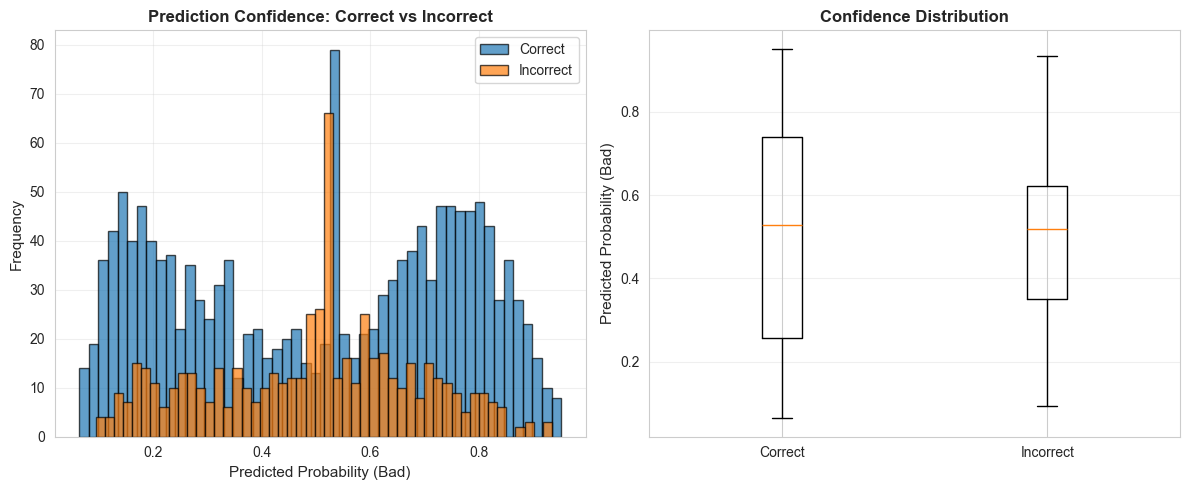

In [16]:
# Analyze misclassifications
X_test_with_preds = X_test.copy()
X_test_with_preds['True_Label'] = y_test.values
X_test_with_preds['Predicted_Label'] = y_pred_optimal
X_test_with_preds['Probability_Bad'] = y_proba_test
X_test_with_preds['Correct'] = (y_test.values == y_pred_optimal)

# False Positives (predicted Bad but actually Good)
false_positives = X_test_with_preds[(X_test_with_preds['True_Label'] == 0) & 
                                     (X_test_with_preds['Predicted_Label'] == 1)]
print(f"False Positives: {len(false_positives)}")
print("\nFalse Positive Statistics:")
print(false_positives[['ExternalRiskEstimate', 'Probability_Bad']].describe())

# False Negatives (predicted Good but actually Bad)
false_negatives = X_test_with_preds[(X_test_with_preds['True_Label'] == 1) & 
                                     (X_test_with_preds['Predicted_Label'] == 0)]
print(f"\nFalse Negatives: {len(false_negatives)}")
print("\nFalse Negative Statistics:")
print(false_negatives[['ExternalRiskEstimate', 'Probability_Bad']].describe())

# Distribution of predicted probabilities for correct vs incorrect
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(X_test_with_preds[X_test_with_preds['Correct']]['Probability_Bad'], 
         bins=50, alpha=0.7, label='Correct', edgecolor='black')
plt.hist(X_test_with_preds[~X_test_with_preds['Correct']]['Probability_Bad'], 
         bins=50, alpha=0.7, label='Incorrect', edgecolor='black')
plt.xlabel('Predicted Probability (Bad)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Prediction Confidence: Correct vs Incorrect', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([X_test_with_preds[X_test_with_preds['Correct']]['Probability_Bad'],
             X_test_with_preds[~X_test_with_preds['Correct']]['Probability_Bad']],
            labels=['Correct', 'Incorrect'])
plt.ylabel('Predicted Probability (Bad)', fontsize=11)
plt.title('Confidence Distribution', fontweight='bold')
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [18]:
# Evaluate against defined objectives
objectives_met = pd.DataFrame({
    'Objective': [
        'ROC-AUC ≥ 0.75',
        'Recall (Bad) ≥ 0.70',
        'Precision (Bad) ≥ 0.65',
        'F1-Score ≥ 0.67',
        'Beat Random Baseline (0.50 AUC)',
        'Beat Majority Baseline (52.2% Acc)',
    ],
    'Target': [0.75, 0.70, 0.65, 0.67, 0.50, 0.522],
    'Achieved': [
        auc_score,
        recall_score(y_test, y_pred_optimal, pos_label=1),
        precision_score(y_test, y_pred_optimal, pos_label=1),
        f1_score(y_test, y_pred_optimal, pos_label=1),
        auc_score,
        accuracy_score(y_test, y_pred_optimal),
    ]
})

objectives_met['Status'] = objectives_met.apply(
    lambda row: 'PASS' if row['Achieved'] >= row['Target'] else 'FAIL', 
    axis=1
)
objectives_met['Margin'] = objectives_met['Achieved'] - objectives_met['Target']

print("\n" + "="*90)
print("FINAL PERFORMANCE ASSESSMENT")
print("="*90)
print(objectives_met.to_string(index=False))
print("="*90)

# Summary verdict
passed = (objectives_met['Status'] == 'PASS').sum()
total = len(objectives_met)
print(f"\n📊 OVERALL: {passed}/{total} objectives met")

if passed == total:
    print("✅ ALL OBJECTIVES ACHIEVED")
elif passed >= total * 0.75:
    print("⚠️  MOSTLY SUCCESSFUL - Minor improvements recommended")
else:
    print("❌ OBJECTIVES NOT MET - Further tuning required")


FINAL PERFORMANCE ASSESSMENT
                         Objective  Target  Achieved Status   Margin
                    ROC-AUC ≥ 0.75   0.750  0.792479   PASS 0.042479
               Recall (Bad) ≥ 0.70   0.700  0.840659   PASS 0.140659
            Precision (Bad) ≥ 0.65   0.650  0.692308   PASS 0.042308
                   F1-Score ≥ 0.67   0.670  0.759305   PASS 0.089305
   Beat Random Baseline (0.50 AUC)   0.500  0.792479   PASS 0.292479
Beat Majority Baseline (52.2% Acc)   0.522  0.721797   PASS 0.199797

📊 OVERALL: 6/6 objectives met
✅ ALL OBJECTIVES ACHIEVED
